# Overfitting & Underfitting: Polynomial Regression Demo

This notebook demonstrates overfitting and underfitting using polynomial curve fitting
on synthetic data generated from `f(x) = sin(2πx)`.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
from src.data_generation import generate_polynomial_data, true_function
from src.polynomial_regression import (
    fit_polynomial,
    evaluate_polynomial_degrees,
    compute_bias_variance,
)
from src.visualization import (
    plot_polynomial_fits,
    plot_error_vs_complexity,
    plot_bias_variance_tradeoff,
    save_figure,
)

## 1. Generate Data

We sample 30 points from `f(x) = sin(2πx)` with Gaussian noise (σ = 0.3).

In [2]:
X, y = generate_polynomial_data(n_samples=30, noise_std=0.3, seed=42)
print(f"Data shape: X={X.shape}, y={y.shape}")

Data shape: X=(30,), y=(30,)


## 2. Polynomial Fits: Underfitting vs. Good Fit vs. Overfitting

- **Degree 1** (underfitting): Too simple, cannot capture the sinusoidal pattern
- **Degree 4** (good fit): Captures the pattern without memorizing noise
- **Degree 15** (overfitting): Memorizes noise, wild oscillations between data points

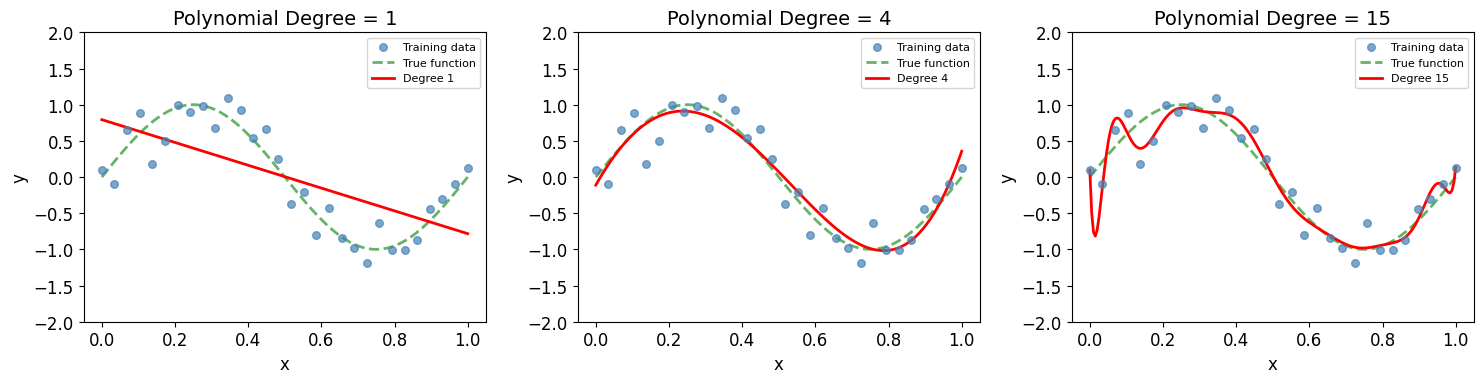

In [3]:
demo_degrees = [1, 4, 15]
coeffs_dict = {}
for d in demo_degrees:
    coeffs_dict[d] = fit_polynomial(X, y, degree=d)

fig = plot_polynomial_fits(X, y, coeffs_dict, true_fn=true_function)
save_figure(fig, "../report/figures/polynomial_fits.png")
fig

## 3. Training Error vs. Test Error

As model complexity increases:
- Training error monotonically decreases (the model fits training data better)
- Test error first decreases then increases (overfitting kicks in)

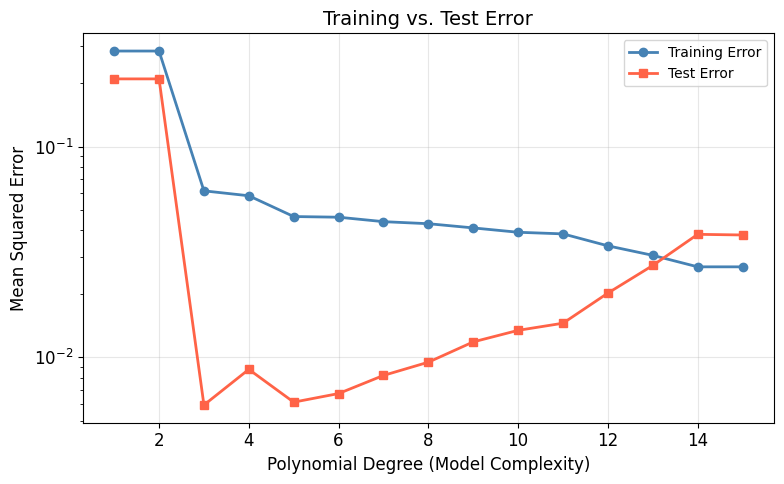

In [4]:
X_test, y_test = generate_polynomial_data(n_samples=100, noise_std=0.0, seed=0)
degrees = list(range(1, 16))
results = evaluate_polynomial_degrees(X, y, X_test, y_test, degrees)

fig = plot_error_vs_complexity(results["degrees"], results["train_errors"], results["test_errors"])
save_figure(fig, "../report/figures/error_vs_complexity.png")
fig

## 4. Bias-Variance Decomposition

$$E[(y - \hat{f}(x))^2] = \text{Bias}^2 + \text{Variance} + \sigma^2$$

We estimate Bias² and Variance via Monte Carlo: generate 200 datasets,
fit a polynomial on each, and measure the spread of predictions.

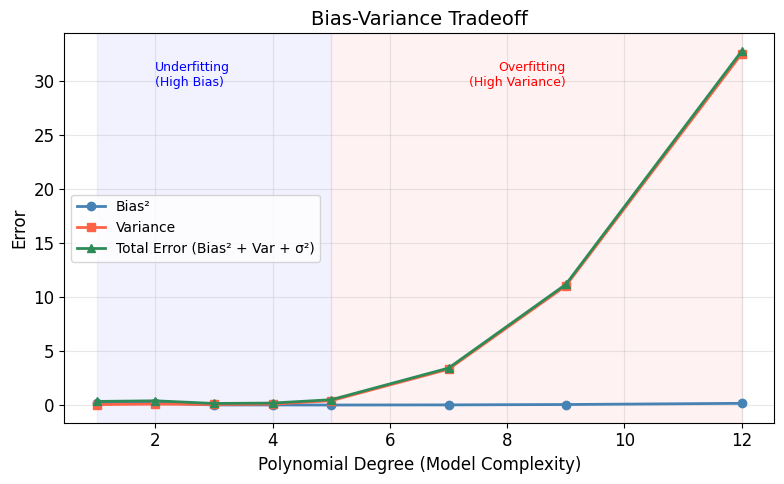

In [5]:
bv_results = compute_bias_variance(
    true_fn=true_function,
    n_samples=20,
    noise_std=0.3,
    degrees=[1, 2, 3, 4, 5, 7, 9, 12],
    n_repeats=200,
    seed=42,
)

fig = plot_bias_variance_tradeoff(
    bv_results["degrees"],
    bv_results["bias_squared"],
    bv_results["variance"],
    bv_results["total_error"],
)
save_figure(fig, "../report/figures/bias_variance_tradeoff.png")
fig